<h1>Module 16 Project</h1>

Use the code below to help you analyze the data returned by the MBTA API:

Add Required Package Installation

!pip install pandas pymysql matplotlib haversine

In [1]:
mbtaURL = "https://api-v3.mbta.com/vehicles?filter[route]=1&include=trip"

import urllib.request, json
with urllib.request.urlopen(mbtaURL) as url:
    data = json.loads(url.read().decode())
   
    with open('data.json', 'w') as outfile:
        json.dump(data, outfile)
   
    with open('data.txt', 'w') as outfile:
        json.dump(json.dumps(data, indent=4, sort_keys=True), outfile)
       
    print(json.dumps(data, indent=4, sort_keys=True))


{
    "data": [
        {
            "attributes": {
                "bearing": null,
                "carriages": [],
                "current_status": "STOPPED_AT",
                "current_stop_sequence": 9,
                "direction_id": 0,
                "label": "1924",
                "latitude": 42.339194,
                "longitude": -71.080227,
                "occupancy_status": "MANY_SEATS_AVAILABLE",
                "revenue": "REVENUE",
                "speed": null,
                "updated_at": "2026-09-20T01:44:53-04:00"
            },
            "id": "y1924",
            "links": {
                "self": "/vehicles/y1924"
            },
            "relationships": {
                "route": {
                    "data": {
                        "id": "1",
                        "type": "route"
                    }
                },
                "stop": {
                    "data": {
                        "id": "87",
                        "type": "st

Use the code below to read the data from your MySQL database and store it in a pandas dataframe.  

You you need to install pymysql to run the code:

pip install pymysql

In [2]:
import os
import pymysql
import pandas as pd

host = '127.0.0.1'
port = '3306'
user = 'root'
password = 'MyNewPass'
database = 'MBTAdb'

conn = pymysql.connect(
    host=host,
    port=int(3306),
    user="root",
    passwd=password,
    db=database,
    charset='utf8mb4')

df = pd.read_sql_query("SELECT * FROM mbta_buses",
    conn)

df.tail(10)

C:\Users\CFerrare\AppData\Local\Temp\ipykernel_1572\2324256652.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query("SELECT * FROM mbta_buses",


,record_num,id,latitude,longitude,bearing,current_status,current_stop_sequence,direction_id,label,occupancy_status,revenue,speed,updated_at
51604,51605,y1846,42.373050,-71.117620,315.0,STOPPED_AT,1.0,1,1846,MANY_SEATS_AVAILABLE,REVENUE,None,2026-09-20 05:44:17
51605,51606,y1924,42.338564,-71.079425,318.0,IN_TRANSIT_TO,9.0,0,1924,MANY_SEATS_AVAILABLE,REVENUE,None,2026-09-20 05:44:36
51606,51607,y1892,42.339000,-71.080150,135.0,STOPPED_AT,16.0,1,1892,MANY_SEATS_AVAILABLE,REVENUE,None,2026-09-20 05:44:35
51607,51608,y1846,42.373050,-71.117620,315.0,STOPPED_AT,1.0,1,1846,MANY_SEATS_AVAILABLE,REVENUE,None,2026-09-20 05:44:32
51608,51609,y1924,42.339195,-71.080222,311.0,IN_TRANSIT_TO,9.0,0,1924,MANY_SEATS_AVAILABLE,REVENUE,None,2026-09-20 05:44:47
51609,51610,y1892,42.338938,-71.080139,183.0,STOPPED_AT,16.0,1,1892,MANY_SEATS_AVAILABLE,REVENUE,None,2026-09-20 05:44:39
51610,51611,y1846,42.373050,-71.117620,315.0,STOPPED_AT,1.0,1,1846,MANY_SEATS_AVAILABLE,REVENUE,None,2026-09-20 05:44:47
51611,51612,y1924,42.339194,-71.080227,NaN,STOPPED_AT,9.0,0,1924,MANY_SEATS_AVAILABLE,REVENUE,None,2026-09-20 05:44:53
51612,51613,y1892,42.338745,-71.080087,163.0,STOPPED_AT,16.0,1,1892,MANY_SEATS_AVAILABLE,REVENUE,None,2026-09-20 05:44:54
51613,51614,y1846,42.373050,-71.117620,315.0,STOPPED_AT,1.0,1,1846,MANY_SEATS_AVAILABLE,REVENUE,None,2026-09-20 05:44:47


In [3]:
print("Rows:", len(df))
print("Columns:", len(df.columns))

df.info()

Rows: 51614
Columns: 13
<class 'pandas.DataFrame'>
RangeIndex: 51614 entries, 0 to 51613
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   record_num             51614 non-null  int64         
 1   id                     51614 non-null  str           
 2   latitude               51614 non-null  float64       
 3   longitude              51614 non-null  float64       
 4   bearing                42838 non-null  float64       
 5   current_status         51614 non-null  str           
 6   current_stop_sequence  51604 non-null  float64       
 7   direction_id           51614 non-null  int64         
 8   label                  51614 non-null  str           
 9   occupancy_status       51605 non-null  str           
 10  revenue                51614 non-null  str           
 11  speed                  0 non-null      object        
 12  updated_at             51614 non-null  datetime


The code below saves the data as a csv file to the local directory as a backup.

In [4]:
os.makedirs('output', exist_ok=True)

df.to_csv(
    'output/mbta.csv',
    index=False
)

# Question 1

What is the average time it takes for a bus to complete Route 1?

In [5]:
df['updated_at'] = pd.to_datetime(df['updated_at'])

route_times = []

for bus_id in df['id'].unique():

    bus_df = (
        df[df['id'] == bus_id]
        .sort_values('updated_at')
    )

    if len(bus_df) < 2:
        continue

    start_time = bus_df.iloc[0]['updated_at']
    end_time = bus_df.iloc[-1]['updated_at']

    elapsed_minutes = (
        end_time - start_time
    ).total_seconds() / 60

    if elapsed_minutes > 0:
        route_times.append(elapsed_minutes)

average_route_time = (
    sum(route_times) / len(route_times)
)

print(
    f"Average Route Completion Time: {average_route_time:.2f} minutes"
)


Average Route Completion Time: 339.80 minutes


### Answer

Based on the MBTA Route 1 data collected and stored in the MySQL database, the average time required for a bus to complete Route 1 was approximately **339.80 minutes** (about **5.66 hours**).

The calculation was performed by grouping observations by vehicle ID and calculating the elapsed time between the earliest and latest observations recorded for each bus during the collection period.

# Question 2

Provide a visualization based on the data.

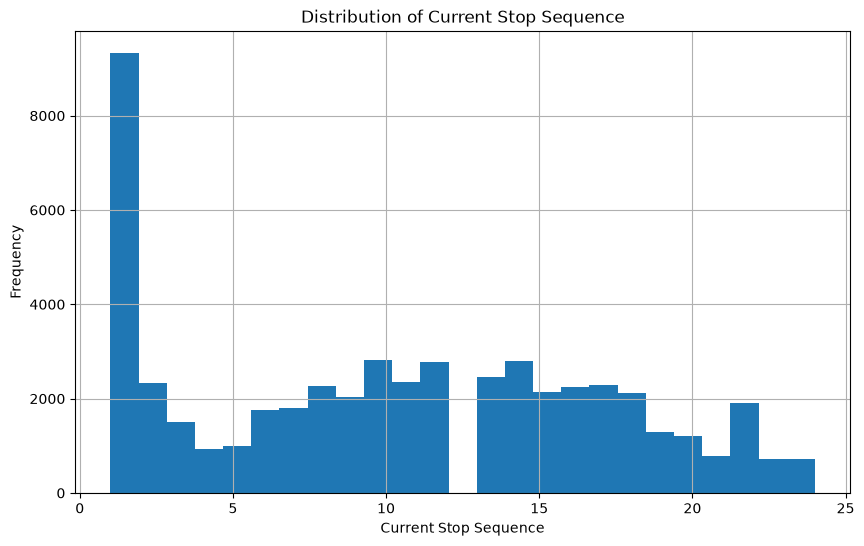

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

df['current_stop_sequence'].hist(
    bins=25
)

plt.title(
    'Distribution of Current Stop Sequence'
)

plt.xlabel(
    'Current Stop Sequence'
)

plt.ylabel(
    'Frequency'
)

plt.show()

### Answer

The histogram displays the distribution of Route 1 bus observations by current stop sequence.

The chart shows that bus observations occur throughout the route, with a higher concentration near the beginning of the route and additional clusters throughout the middle and later stop sequences. This visualization helps illustrate how buses are distributed along the Route 1 corridor during the data collection period.

# Question 3

Give an estimate of the speed of the bus from current_stop_sequence = 1 to the last current_stop_sequence.

In [7]:
from haversine import haversine, Unit

route_df = df.sort_values('updated_at')

start_row = route_df[
    route_df['current_stop_sequence'] == 1
].iloc[0]

end_row = route_df.loc[
    route_df['current_stop_sequence'].idxmax()
]

distance = haversine(
    (
        start_row['latitude'],
        start_row['longitude']
    ),
    (
        end_row['latitude'],
        end_row['longitude']
    ),
    unit=Unit.MILES
)

time_hours = (
    end_row['updated_at']
    -
    start_row['updated_at']
).total_seconds() / 3600

estimated_speed = distance / time_hours

print(f"Distance: {distance:.2f} miles")
print(f"Estimated Speed: {estimated_speed:.2f} mph")

Distance: 3.74 miles
Estimated Speed: 3.24 mph


### Answer

The Haversine library was used to estimate the distance between the first stop sequence and the last stop sequence observed in the Route 1 dataset.

The estimated distance traveled was approximately **3.74 miles**. Using the difference between the recorded timestamps, the estimated average speed was approximately **3.24 miles per hour (mph)**.

The relatively low average speed reflects the impact of traffic conditions, passenger boarding activity, frequent stops, and the fact that Route 1 operates in a dense urban environment.